# Aula 02 Hands-On — MLP, Backpropagation e Gradientes em Dígitos

## Contexto
Nesta prática, saímos do caso geométrico em 2D e passamos para um problema multiclasse real, ainda pequeno o bastante para manter o experimento rápido e legível. O foco é observar como um MLP aprende representações úteis via backpropagation e como o fluxo de gradiente afeta a dinâmica de treinamento.

## Objetivos de aprendizagem
- Comparar uma regressão logística sobre pixels achatados com um MLP raso treinado por gradiente descendente.
- Acompanhar `cross-entropy`, acurácia, macro-F1 e normas de gradiente ao longo das épocas.
- Relacionar a melhora do MLP à capacidade de aprender representações não lineares, e não apenas a mais parâmetros.
- Inspecionar erros para entender quais dígitos continuam ambíguos mesmo depois do treinamento.

## Pergunta experimental e hipótese
**Pergunta:** em um problema visual multiclasse pequeno, um MLP já produz ganho mensurável sobre um baseline linear quando treinado com backpropagation?

**Hipótese:**
- A regressão logística deve ser um baseline forte, porque o dataset de dígitos é relativamente bem comportado.
- O MLP deve superar o baseline ao modelar combinações não lineares entre pixels.
- Se o gradiente permanecer estável nas primeiras camadas, a curva de validação deve melhorar sem colapsar para overfitting prematuro.

## Setup, imports e semente de reprodutibilidade
Usaremos `sklearn` para o dataset e o baseline linear, além de `PyTorch` para o MLP. A semente fixa controla particionamento, inicialização e shuffling dos lotes.

In [1]:
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)  # tabelas com 4 casas, como citadas na apostila
device

'cuda'

## Carregamento do dataset e preparação das partições
O `digits` do `sklearn` tem imagens 8x8 em escala de cinza, o que o torna ideal para um experimento didático: há estrutura visual suficiente para justificar uma rede neural, mas o custo computacional continua baixo. A divisão treino-validação-teste evita usar o conjunto final para ajuste implícito de hiperparâmetros.

,amostras_treino
classe,
0,107
1,109
2,106
3,110
4,109
5,109
6,109
7,107
8,104


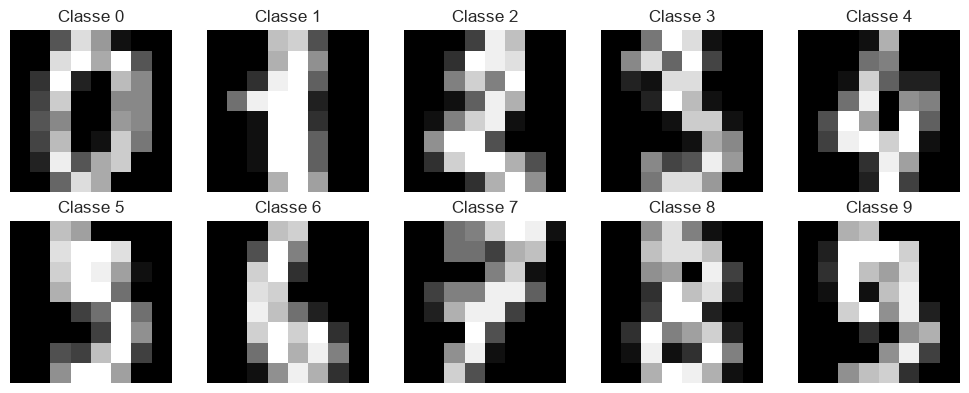

In [2]:
digits = load_digits()
X = digits.data.astype(np.float32) / 16.0
y = digits.target.astype(np.int64)
images = digits.images

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

def make_loader(features, targets, batch_size=128, shuffle=False):
    dataset = TensorDataset(torch.tensor(features), torch.tensor(targets))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f'Classe {y[idx]}')
    ax.axis('off')
plt.tight_layout()

pd.Series(y_train).value_counts().sort_index().rename_axis('classe').to_frame('amostras_treino')

## Baseline e por que ele importa
A regressão logística multinomial é um baseline forte porque otimiza probabilidades diretamente e já captura boa parte da separabilidade do dataset. Se o MLP não superar esse baseline, a conclusão correta não é que backpropagation falhou, mas que a complexidade extra talvez não tenha agregado informação útil para este regime.

In [3]:
baseline_model = LogisticRegression(
    max_iter=1500,
    solver='lbfgs',
    random_state=SEED,
)

## Método principal
O método principal será um MLP de duas camadas ocultas com ReLU. Além da loss e da acurácia, registraremos a norma dos gradientes da primeira e da última camada. Isso transforma o notebook em um pequeno laboratório de backpropagation: conseguimos ver se o sinal de erro chega ao início da rede com magnitude saudável.

In [4]:
class DigitsMLP(nn.Module):
    def __init__(self, input_dim=64, hidden_dims=(128, 64), num_classes=10, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], num_classes),
        )

    def forward(self, x):
        return self.net(x)

def evaluate_torch_model(model, loader, criterion):
    model.eval()
    losses, probs_list, preds_list, targets_list = [], [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            losses.append(loss.item())
            probs_list.append(probs.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
            targets_list.append(yb.cpu().numpy())

    y_true = np.concatenate(targets_list)
    y_pred = np.concatenate(preds_list)
    y_prob = np.concatenate(probs_list)
    return {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'log_loss': log_loss(y_true, y_prob),
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
    }

def train_mlp(model, train_loader, val_loader, epochs=30, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    best_state, best_val_loss = None, float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []
        first_grad, last_grad = [], []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            first_grad.append(model.net[0].weight.grad.norm().item())
            last_grad.append(model.net[-1].weight.grad.norm().item())

            optimizer.step()
            batch_losses.append(loss.item())

        train_metrics = evaluate_torch_model(model, train_loader, criterion)
        val_metrics = evaluate_torch_model(model, val_loader, criterion)
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_macro_f1': val_metrics['macro_f1'],
            'first_layer_grad_norm': float(np.mean(first_grad)),
            'last_layer_grad_norm': float(np.mean(last_grad)),
        })

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return pd.DataFrame(history), criterion

## Métricas e interpretação
`Cross-entropy` é a função objetivo principal, porque queremos probabilidades bem calibradas por classe. Acurácia resume desempenho global, enquanto macro-F1 pune degradações concentradas em classes específicas. As normas de gradiente ajudam a distinguir um treino saudável de um cenário em que as primeiras camadas praticamente deixam de aprender.

In [5]:
def evaluate_baseline(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)
    preds = probs.argmax(axis=1)
    return {
        'accuracy': accuracy_score(y_test, preds),
        'macro_f1': f1_score(y_test, preds, average='macro'),
        'log_loss': log_loss(y_test, probs),
        'y_pred': preds,
        'y_prob': probs,
    }

## Execução do treinamento e da avaliação
A rotina abaixo treina o baseline linear e o MLP sob a mesma partição. As tabelas exibidas logo após o treino trazem a comparação final no teste (`comparison_df`), as primeiras épocas de `history_df` e a época em que cada norma de gradiente atinge o pico. Em seguida inspecionamos as curvas de loss, a acurácia de validação, a matriz de confusão (impressa e desenhada) e a evolução das normas de gradiente. Se o MLP estiver aprendendo de forma estável, o gradiente da primeira camada não deve colapsar para zero cedo demais.

,modelo,accuracy,macro_f1,log_loss
0,Regressão logística,0.9556,0.9555,0.1894
1,MLP com backpropagation,0.9583,0.9584,0.1429


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,first_layer_grad_norm,last_layer_grad_norm
0,1,2.2316,0.3952,2.2332,0.4039,0.3300,0.0966,0.0943
1,2,2.1208,0.7171,2.1224,0.6992,0.6901,0.1471,0.1528
2,3,1.9384,0.7059,1.9459,0.7242,0.7185,0.1936,0.2433
3,4,1.6877,0.7718,1.6884,0.7716,0.7648,0.2382,0.3591
4,5,1.3774,0.8024,1.3746,0.8050,0.7970,0.2928,0.4845


,epoch,first_layer_grad_norm,last_layer_grad_norm
8,9,0.3113,0.6343
9,10,0.2795,0.6522


Matriz de confusão (linhas = real, colunas = predito):
[[34  0  0  0  1  0  0  0  0  0]
 [ 0 34  0  0  0  1  1  0  1  0]
 [ 0  4 31  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 35  0  0  0  1  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  2  1  0  0  0  0  0 32  0]
 [ 0  0  0  0  0  0  0  2  0 34]]


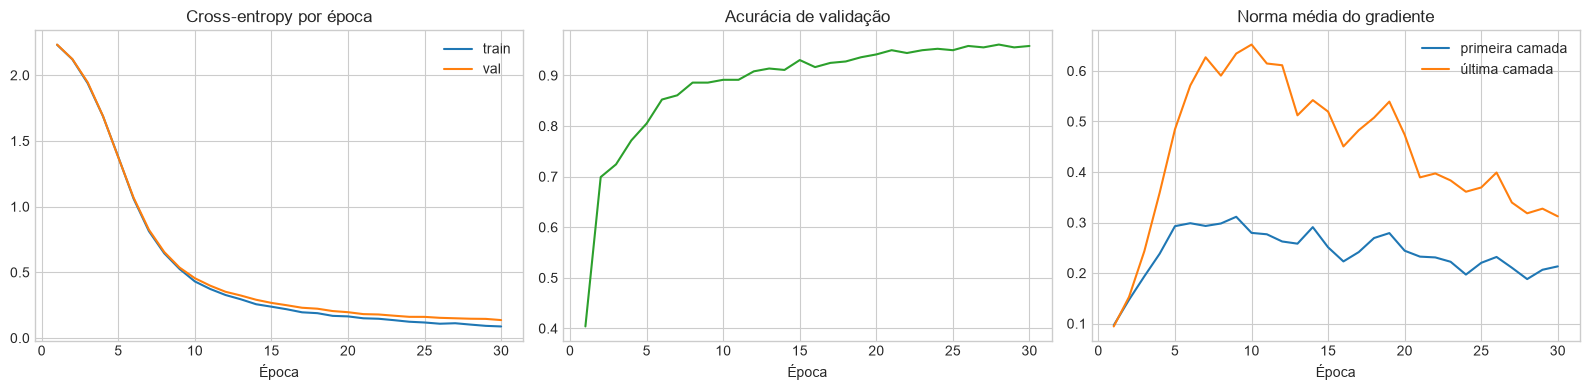

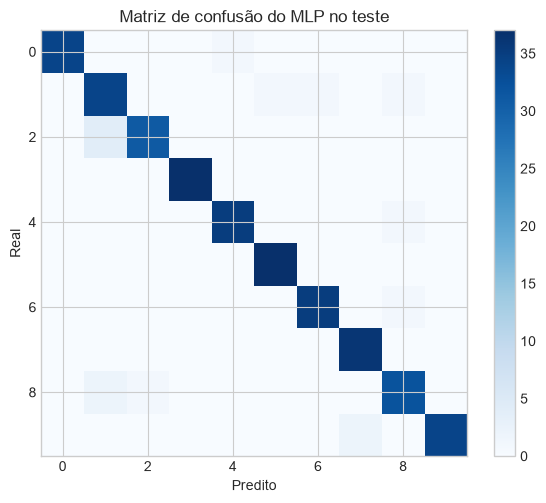

In [6]:
baseline_metrics = evaluate_baseline(baseline_model, X_train, y_train, X_test, y_test)

mlp_model = DigitsMLP().to(device)
history_df, criterion = train_mlp(mlp_model, train_loader, val_loader, epochs=30, lr=1e-3)
mlp_metrics = evaluate_torch_model(mlp_model, test_loader, criterion)

comparison_df = pd.DataFrame([
    {
        'modelo': 'Regressão logística',
        'accuracy': baseline_metrics['accuracy'],
        'macro_f1': baseline_metrics['macro_f1'],
        'log_loss': baseline_metrics['log_loss'],
    },
    {
        'modelo': 'MLP com backpropagation',
        'accuracy': mlp_metrics['accuracy'],
        'macro_f1': mlp_metrics['macro_f1'],
        'log_loss': mlp_metrics['log_loss'],
    },
])
display(comparison_df)

# Primeiras épocas (a tabela completa está em history_df; o final aparece na última célula)
display(history_df.head())

# Época em que cada norma de gradiente atinge o pico
grad_peaks_df = history_df.loc[
    history_df[['first_layer_grad_norm', 'last_layer_grad_norm']].idxmax().values,
    ['epoch', 'first_layer_grad_norm', 'last_layer_grad_norm'],
]
display(grad_peaks_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val')
axes[0].set_title('Cross-entropy por época')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_accuracy'], color='tab:green')
axes[1].set_title('Acurácia de validação')
axes[1].set_xlabel('Época')

axes[2].plot(history_df['epoch'], history_df['first_layer_grad_norm'], label='primeira camada')
axes[2].plot(history_df['epoch'], history_df['last_layer_grad_norm'], label='última camada')
axes[2].set_title('Norma média do gradiente')
axes[2].set_xlabel('Época')
axes[2].legend()
plt.tight_layout()

cm = confusion_matrix(mlp_metrics['y_true'], mlp_metrics['y_pred'])
print('Matriz de confusão (linhas = real, colunas = predito):')
print(cm)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusão do MLP no teste')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.colorbar()
plt.tight_layout()

## Análise de erro, limitações e próximo experimento
Mesmo quando o MLP supera o baseline linear, alguns dígitos continuam difíceis por ambiguidade visual intrínseca, como 1 versus 7 ou 3 versus 9 mal escritos. O próximo experimento natural é variar ativação, largura e inicialização para ver quanto do ganho vem de capacidade e quanto vem de condições numéricas melhores para o gradiente.

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,first_layer_grad_norm,last_layer_grad_norm
25,26,0.1087,0.9787,0.1536,0.9582,0.9583,0.2318,0.3989
26,27,0.1124,0.9796,0.1502,0.9554,0.9554,0.2106,0.3396
27,28,0.1021,0.9796,0.1467,0.9610,0.9612,0.1880,0.3182
28,29,0.0926,0.9787,0.1455,0.9554,0.9559,0.2065,0.3274
29,30,0.0879,0.9796,0.1364,0.9582,0.9580,0.2132,0.3122


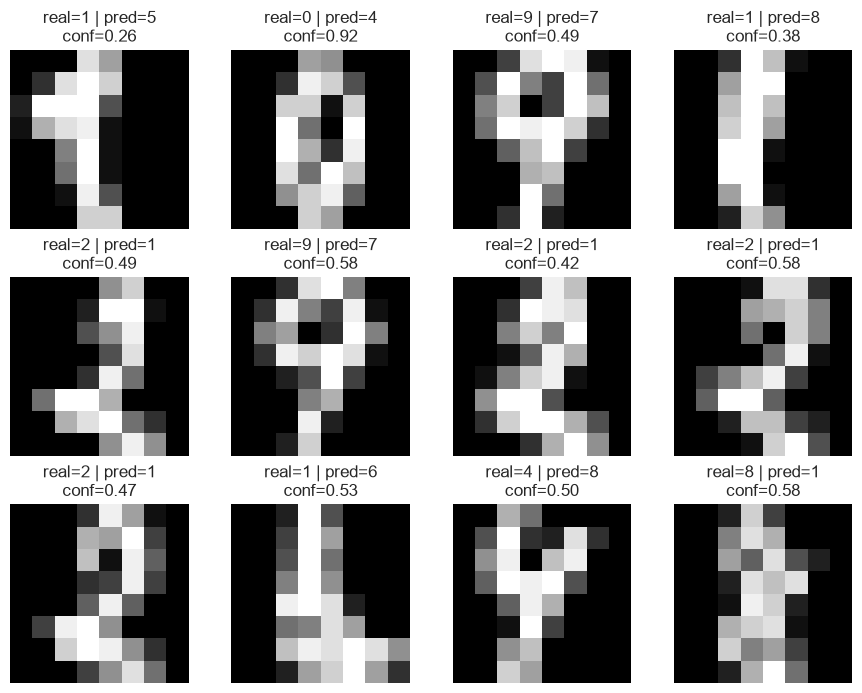

In [7]:
mis_idx = np.where(mlp_metrics['y_true'] != mlp_metrics['y_pred'])[0][:12]
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for ax, idx in zip(axes.flat, mis_idx):
    ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
    confidence = mlp_metrics['y_prob'][idx].max()
    ax.set_title(f"real={y_test[idx]} | pred={mlp_metrics['y_pred'][idx]}\nconf={confidence:.2f}")
    ax.axis('off')
plt.tight_layout()

history_df.tail()

## Fechamento e próximos passos
Se a hipótese estiver correta, o MLP deve entregar ganho consistente sobre a regressão logística e manter gradientes úteis ao longo do treinamento. Esse resultado prepara o próximo salto do curso: em vez de tratar cada pixel como uma feature independente, vamos explorar a estrutura espacial das imagens com convoluções e mostrar por que CNNs são uma resposta arquitetural mais adequada para visão computacional.